In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import joblib
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

# Grafik-Stil
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# 1. PARAMETER
WINDOW_LEN = 155
INPUT_TRAIN = 'training_data_nan_bereinigt.csv'
INPUT_TEST = 'test_data_nan_bereinigt.csv'

# Name für das finale Modell
MODEL_FILE = 'sonar_model_combined_traing_data.pkl'

print("Bibliotheken geladen. Konfiguration bereit.")

Bibliotheken geladen. Konfiguration bereit.


In [256]:
def natural_sort_key(s):
    """Sortiert S_2 vor S_10 (natürliche Ordnung)."""
    return [int(text) if text.isdigit() else text.lower() for text in re.split('(\d+)', s)]


def process_signal_fast(sig, win_len, p_mask, v_start):
    """
    Extrahiert Features und das ausgerichtete Fenster (Aligned Window).
    Implementiert Peak-Search, Valley-Search und Onset-Detection.
    """
    sig_len = len(sig)

    # 1. Peak Search (maskiert)
    roi_start = min(sig_len, p_mask)
    if roi_start >= sig_len:
        peak_idx = 0
    else:
        peak_idx = roi_start + np.argmax(sig[roi_start:])
    peak_val_raw = sig[peak_idx] if peak_idx < sig_len else 0

    # 2. Valley Search
    v_s = min(sig_len, v_start)
    v_e = peak_idx
    if v_s >= v_e:
        valley_idx = v_s
    else:
        valley_idx = v_s + np.argmin(sig[v_s:v_e])
    valley_val = sig[valley_idx] if valley_idx < sig_len else 0

    # 3. Onset Detection (10% Threshold vom Valley zum Peak)
    threshold = valley_val + (peak_val_raw - valley_val) * 0.10
    rise_segment = sig[valley_idx:peak_idx] if valley_idx < peak_idx else np.array([
    ])

    if len(rise_segment) == 0:
        onset_abs = valley_idx
    else:
        below_idx = np.where(rise_segment < threshold)[0]
        # Letzter Punkt unter Threshold ist der Start
        onset_abs = valley_idx + (below_idx[-1] if len(below_idx) > 0 else 0)

    # 4. Fenster ausschneiden (Alignment)
    start_idx = onset_abs
    end_idx = start_idx + win_len
    aligned_window = np.zeros(win_len)

    # Safe Slicing
    read_start = max(0, start_idx)
    read_end = min(sig_len, end_idx)
    write_start = read_start - start_idx
    write_end = write_start + (read_end - read_start)

    if read_start < read_end and write_start < win_len:
        aligned_window[write_start:write_end] = sig[read_start:read_end]

    # 5. Features berechnen
    raw_energy = np.sum(aligned_window**2)
    s_val = np.std(aligned_window)
    m_val = np.mean(aligned_window)

    # Z-Score Normalisierung
    if s_val > 1e-9:
        aligned_window_norm = (aligned_window - m_val) / s_val
    else:
        aligned_window_norm = aligned_window - m_val

    # Peak Stats im Fenster
    loc = peak_idx - start_idx
    loc = max(0, min(win_len - 1, loc))
    peak_norm = aligned_window_norm[loc]

    # Breite (FWHM)
    half_val = peak_norm * 0.5
    left_part = aligned_window_norm[:loc]
    left_idxs = np.where(left_part < half_val)[0]
    left_idx = left_idxs[-1] if len(left_idxs) > 0 else 0

    right_part = aligned_window_norm[loc:]
    right_idxs = np.where(right_part < half_val)[0]
    width_idx = (loc + right_idxs[0]) if len(right_idxs) > 0 else (win_len - 1)
    width = width_idx - left_idx

    return [raw_energy, peak_val_raw, peak_norm, width], aligned_window_norm


def load_and_extract(filename, win_len):
    """Lädt CSV, bereinigt NaNs, sortiert Spalten und extrahiert Features."""
    # Laden
    try:
        df = pd.read_csv(filename, sep=';')
    except:
        df = pd.read_csv(filename, sep=',')
    df.columns = df.columns.str.strip()

    # NaN Fix
    if df.isna().sum().sum() > 0:
        df.fillna(0, inplace=True)

    # Split High/Low & Sortieren nach Zeit
    df_high = df[df['Frequency'].str.lower(
    ) == 'high'].copy().sort_values('Timestamp')
    df_low = df[df['Frequency'].str.lower(
    ) == 'low'].copy().sort_values('Timestamp')

    # Länge angleichen
    n = min(len(df_high), len(df_low))
    df_high = df_high.iloc[:n]
    df_low = df_low.iloc[:n]

    # Spalten sortieren (S_1, S_2, ... S_10)
    hf_cols = sorted(
        [c for c in df_high.columns if c.startswith('S_')], key=natural_sort_key)
    lf_cols = sorted(
        [c for c in df_low.columns if c.startswith('S_')], key=natural_sort_key)

    data_hf = df_high[hf_cols].values
    data_lf = df_low[lf_cols].values
    labels = df_high['class_name'].values

    # Feature Extraction Loop
    num_samples = len(labels)
    # Struktur: 8 Stats + HF_Wave + LF_Wave
    X = np.zeros((num_samples, 8 + 2 * win_len))

    for i in range(num_samples):
        stats_hf, win_hf = process_signal_fast(data_hf[i], win_len, 30, 20)
        stats_lf, win_lf = process_signal_fast(data_lf[i], win_len, 78, 55)
        X[i, :] = np.concatenate([stats_hf, stats_lf, win_hf, win_lf])

    return X, labels, data_hf, data_lf

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/var/folders/q1/8hg_82hj68527jpx97n4zm440000gn/T/ipykernel_46657/42576002.py:3: SyntaxWarning: invalid escape sequence '\d'
  return [int(text) if text.isdigit() else text.lower() for text in re.split('(\d+)', s)]


In [257]:
# Container
X_list, Y_list = [], []
Raw_HF_list, Raw_LF_list = [], []

# 1. Training laden
if os.path.exists(INPUT_TRAIN):
    print(f"Lade Training Set: {INPUT_TRAIN}")
    x, y, raw_h, raw_l = load_and_extract(INPUT_TRAIN, WINDOW_LEN)
    X_list.append(x)
    Y_list.append(y)
    Raw_HF_list.append(raw_h)
    Raw_LF_list.append(raw_l)
else:
    print(f"FEHLER: {INPUT_TRAIN} fehlt!")

# 2. Test laden (und fusionieren)
if os.path.exists(INPUT_TEST):
    print(f"Lade Test Set (Fusion): {INPUT_TEST}")
    x, y, raw_h, raw_l = load_and_extract(INPUT_TEST, WINDOW_LEN)
    X_list.append(x)
    Y_list.append(y)
    Raw_HF_list.append(raw_h)
    Raw_LF_list.append(raw_l)

# 3. Zusammenfügen
if X_list:
    X_full_raw = np.concatenate(X_list, axis=0)
    Y_full = np.concatenate(Y_list, axis=0)
    Raw_HF_full = np.concatenate(Raw_HF_list, axis=0)
    Raw_LF_full = np.concatenate(Raw_LF_list, axis=0)

    print("\n--- DATEN FUSIONIERT ---")
    print(f"Gesamtanzahl Samples: {len(Y_full)}")
    unique, counts = np.unique(Y_full, return_counts=True)
    print("Klassen:", dict(zip(unique, counts)))
else:
    raise ValueError("Keine Daten geladen!")

Lade Training Set: training_data_nan_bereinigt.csv
Lade Test Set (Fusion): test_data_nan_bereinigt.csv

--- DATEN FUSIONIERT ---
Gesamtanzahl Samples: 72
Klassen: {'Gravel': np.int64(24), 'Sand': np.int64(24), 'Stones': np.int64(24)}


Detail-Analyse für Sample 0 (Sand):


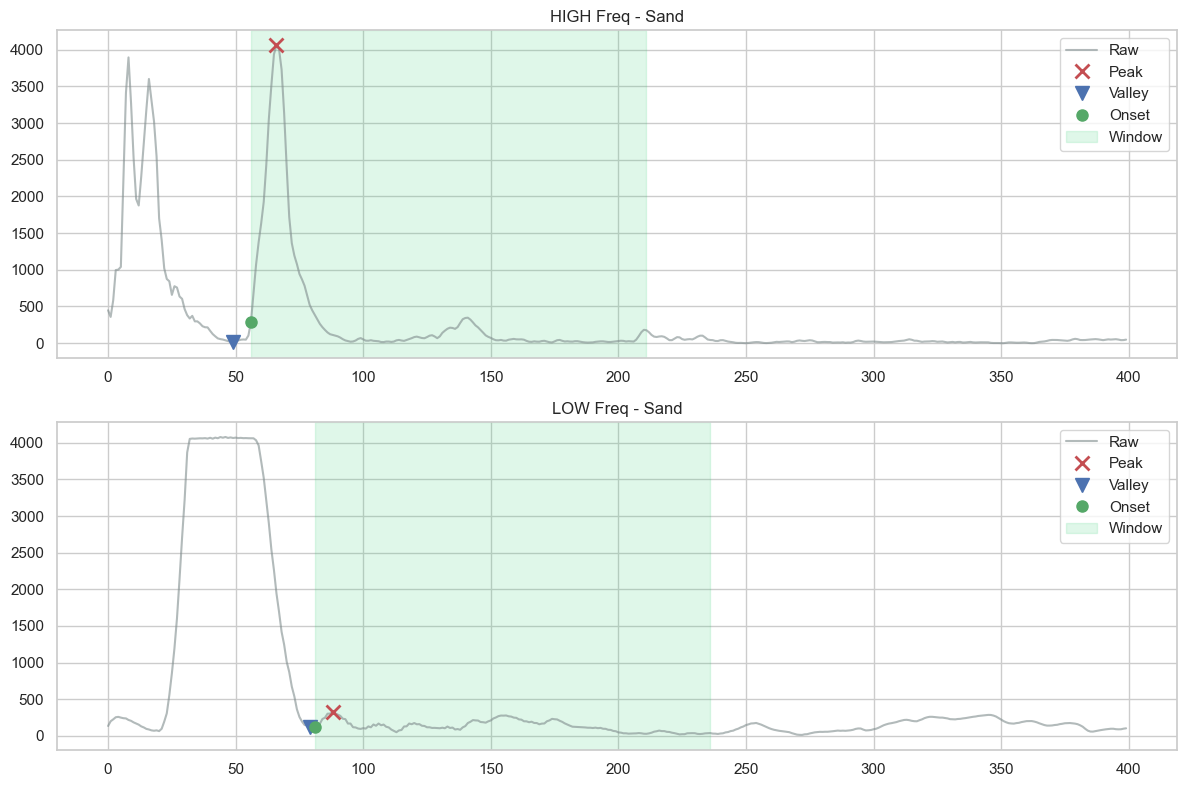

In [258]:
def plot_signal_details(ax, sig, win_len, p_mask, v_start, title):
    """Zeichnet Rohsignal mit Peak, Valley, Onset und Fenster."""
    # (Logik identisch zu oben, nur für Plotting)
    sig_len = len(sig)
    roi_start = min(sig_len, p_mask)
    peak_idx = roi_start + \
        np.argmax(sig[roi_start:]) if roi_start < sig_len else 0

    v_s = min(sig_len, v_start)
    v_e = peak_idx
    valley_idx = v_s + np.argmin(sig[v_s:v_e]) if v_s < v_e else v_s

    threshold = sig[valley_idx] + (sig[peak_idx] - sig[valley_idx]) * 0.10
    rise = sig[valley_idx:peak_idx] if valley_idx < peak_idx else []

    onset_abs = valley_idx
    if len(rise) > 0:
        below = np.where(rise < threshold)[0]
        if len(below) > 0:
            onset_abs = valley_idx + below[-1]

    # Plot
    ax.plot(sig, color='#7f8c8d', alpha=0.6, label='Raw')
    ax.plot(peak_idx, sig[peak_idx], 'rx', ms=10,
            markeredgewidth=2, label='Peak')
    ax.plot(valley_idx, sig[valley_idx], 'bv', ms=10, label='Valley')
    ax.plot(onset_abs, sig[onset_abs], 'go', ms=8, label='Onset')
    ax.axvspan(onset_abs, onset_abs + win_len,
               color='#2ecc71', alpha=0.15, label='Window')
    ax.set_title(title)
    ax.legend(loc='upper right')


# Plot für Sample 0
idx = 0
lbl = Y_full[idx]
print(f"Detail-Analyse für Sample {idx} ({lbl}):")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_signal_details(axes[0], Raw_HF_full[idx],
                    WINDOW_LEN, 30, 20, f"HIGH Freq - {lbl}")
plot_signal_details(axes[1], Raw_LF_full[idx],
                    WINDOW_LEN, 78, 55, f"LOW Freq - {lbl}")
plt.tight_layout()
plt.show()

Visualisiere Durchschnittssignale aller gesammelten Daten...


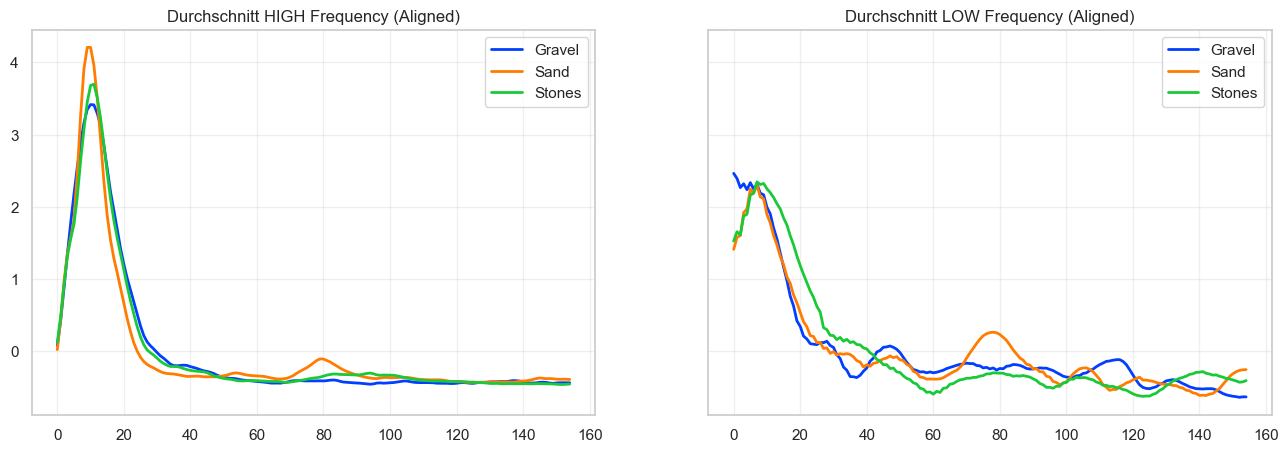

In [259]:
print("Visualisiere Durchschnittssignale aller gesammelten Daten...")
classes = np.unique(Y_full)
hf_start, hf_end = 8, 8 + WINDOW_LEN
lf_start, lf_end = 8 + WINDOW_LEN, 8 + 2 * WINDOW_LEN

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
colors = sns.color_palette("bright", len(classes))

for i, cls in enumerate(classes):
    mask = (Y_full == cls)
    mean_hf = np.mean(X_full_raw[mask, hf_start:hf_end], axis=0)
    mean_lf = np.mean(X_full_raw[mask, lf_start:lf_end], axis=0)

    axes[0].plot(mean_hf, label=f"{cls}", color=colors[i], lw=2)
    axes[1].plot(mean_lf, label=f"{cls}", color=colors[i], lw=2)

axes[0].set_title("Durchschnitt HIGH Frequency (Aligned)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].set_title("Durchschnitt LOW Frequency (Aligned)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

In [260]:
# Feature Split
NUM_STATS = 8
X_stats = X_full_raw[:, :NUM_STATS]
X_wave = X_full_raw[:, NUM_STATS:]

# 1. Standardisierung
scaler = StandardScaler()
X_wave_std = scaler.fit_transform(X_wave)

# 2. PCA (24% Varianz Limit)
print("Berechne PCA...")
pca = PCA(n_components=0.5, random_state=42)
X_pca = pca.fit_transform(X_wave_std)

print(f"   -> {pca.n_components_} Komponenten behalten.")

# 3. Hybrid Features
X_final = np.hstack([X_stats, X_pca])
print(f"Finale Matrix Shape: {X_final.shape}")

Berechne PCA...
   -> 7 Komponenten behalten.
Finale Matrix Shape: (72, 15)


In [261]:
# Optimierte Parameter (aus Grid Search)
BEST_PARAMS = {
    'n_estimators': 800,
    'max_features': 'sqrt',
    'min_samples_leaf': 3,
    'class_weight': None,
    'oob_score': True,
    'random_state': 42,
    'n_jobs': -1
}

print(f"Trainiere finales Modell mit Parametern: {BEST_PARAMS}")

model = RandomForestClassifier(**BEST_PARAMS)
model.fit(X_final, Y_full)

# OOB Score
oob_score = model.oob_score_
print("========================================")
print(f"FINALER OOB SCORE: {oob_score * 100:.2f}%")
print("========================================")

Trainiere finales Modell mit Parametern: {'n_estimators': 800, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'class_weight': None, 'oob_score': True, 'random_state': 42, 'n_jobs': -1}
FINALER OOB SCORE: 81.94%


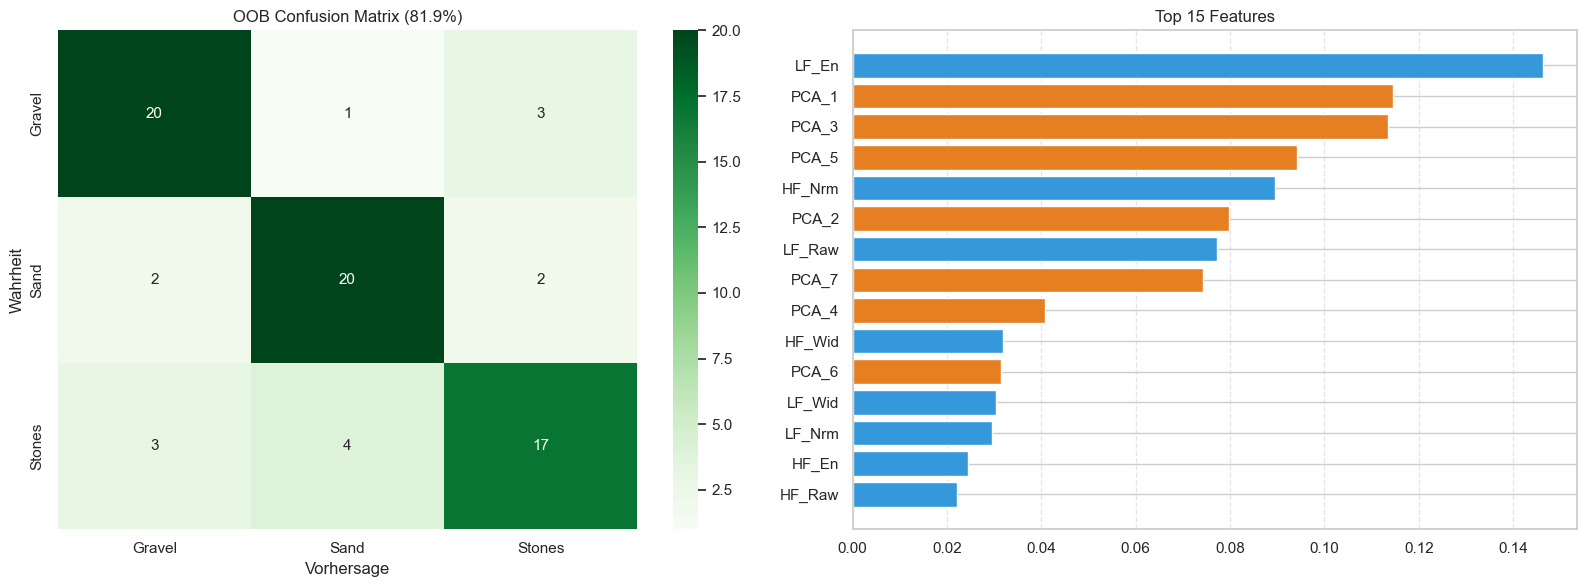

In [262]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Confusion Matrix
cm = confusion_matrix(Y_full, Y_pred_oob)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=model.classes_, yticklabels=model.classes_)
axes[0].set_title(f"OOB Confusion Matrix ({oob_score*100:.1f}%)")
axes[0].set_ylabel("Wahrheit")
axes[0].set_xlabel("Vorhersage")

# 2. Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
num_pca = pca.n_components_

# Namen
feat_names = ['HF_En', 'HF_Raw', 'HF_Nrm', 'HF_Wid', 'LF_En', 'LF_Raw',
              'LF_Nrm', 'LF_Wid'] + [f'PCA_{i+1}' for i in range(num_pca)]

# Top N Plot
top_n = min(15, len(importances))
top_idx = indices[:top_n]
# Blau=Physik, Orange=PCA
bar_colors = ['#3498db' if i < 8 else '#e67e22' for i in top_idx]

axes[1].barh(range(top_n), importances[top_idx],
             color=bar_colors, align='center')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels([feat_names[i] for i in top_idx])
axes[1].invert_yaxis()
axes[1].set_title(f"Top {top_n} Features")
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [263]:
joblib.dump({
    'model': model,
    'pca': pca,
    'scaler': scaler,
    'oob_score': oob_score,
    'params': BEST_PARAMS
}, MODEL_FILE)
print(f"Modell gespeichert als: {MODEL_FILE}")

Modell gespeichert als: sonar_model_FULL_DATA_optimized.pkl
